## Calculating displacement due to faulting

This notebook will calculate _displacement_ at specified points due to slip on a fault. 

In [59]:
# Import libraries
import pandas as pd
import numpy as np # Numerical analysis
import gmsh # Creation of fault models
import meshio # Interaction between fault model files and Python
import matplotlib.pyplot as plt # Visualize 
from pyproj import Proj
import pyproj
import h5py
%matplotlib widget

In [60]:
# Define some basic coordinate transformation functions
GEOID = pyproj.Geod(ellps="WGS84")
KM2M = 1.0e3
RADIUS_EARTH = np.float64((GEOID.a + GEOID.b) / 2)

def sph2cart(lon, lat, radius):
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)
    x = radius * np.cos(lat_rad) * np.cos(lon_rad)
    y = radius * np.cos(lat_rad) * np.sin(lon_rad)
    z = radius * np.sin(lat_rad)
    return x, y, z

def cart2sph(x, y, z):
    azimuth = np.arctan2(y, x)
    elevation = np.arctan2(z, np.sqrt(x ** 2 + y ** 2))
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    return azimuth, elevation, r

def wrap2360(lon):
    lon[np.where(lon < 0.0)] += 360.0
    return lon

## Initial Set-up 

This code reads in horiz.msh, a flat horizontal mesh created to represent the surface between the lithosphere and the asthenosphere in the mantle. ```filename``` can be changed to read a different mesh, producing different results when slip is applied. ```xs``` and ```ys``` are used to create the grid that displacement is calculated on. The size of the grid can be altered by changing the first two values in either variable that represent longitude and latitude respectively, and the third alters the complexity (the total number of points generated between the two selected coordinates). The first plot shows the grid as a red rectangle on the coastline, and the second colors each element of the mesh by its strike. (Strikes of 180 and 0 are different colors and values, but functionally represent the same thing).

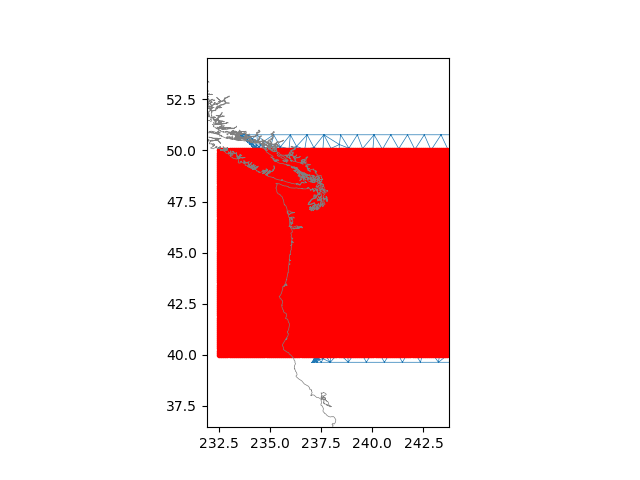

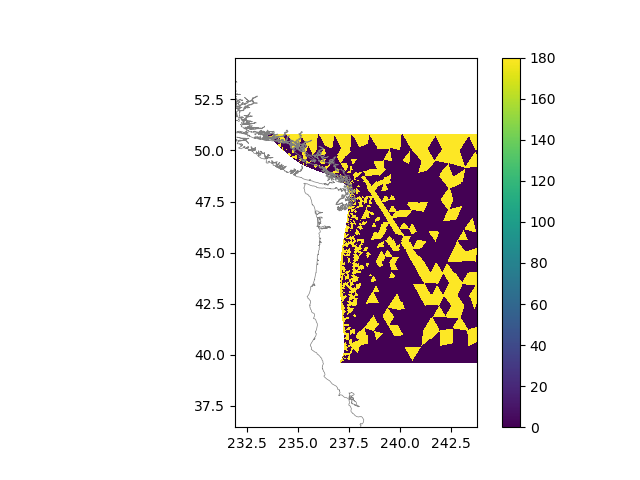

-0.0
180.0
231.90608599856742


In [61]:
# Read in source fault
filename = "new_horiz.msh"
# filename = "japan.msh"
mesh = dict()
meshobj = meshio.read(filename)
mesh["file_name"] = filename
mesh["points"] = meshobj.points
mesh["verts"] = meshio.CellBlock("triangle", meshobj.get_cells_type("triangle")).data
ntri = len(mesh["verts"])

# Expand mesh coordinates
mesh["lon1"] = mesh["points"][mesh["verts"][:, 0], 0]
mesh["lon2"] = mesh["points"][mesh["verts"][:, 1], 0]
mesh["lon3"] = mesh["points"][mesh["verts"][:, 2], 0]
mesh["lat1"] = mesh["points"][mesh["verts"][:, 0], 1]
mesh["lat2"] = mesh["points"][mesh["verts"][:, 1], 1]
mesh["lat3"] = mesh["points"][mesh["verts"][:, 2], 1]
mesh["dep1"] = mesh["points"][mesh["verts"][:, 0], 2]
mesh["dep2"] = mesh["points"][mesh["verts"][:, 1], 2]
mesh["dep3"] = mesh["points"][mesh["verts"][:, 2], 2]
mesh["centroids"] = np.mean(mesh["points"][mesh["verts"], :], axis=1)

# Cross products for orientations
tri_leg1 = np.transpose([np.deg2rad(mesh["lon2"] - mesh["lon1"]), np.deg2rad(mesh["lat2"] - mesh["lat1"]), (1 + KM2M * mesh["dep2"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep1"] / RADIUS_EARTH)])
tri_leg2 = np.transpose([np.deg2rad(mesh["lon3"] - mesh["lon2"]), np.deg2rad(mesh["lat3"] - mesh["lat2"]), (1 + KM2M * mesh["dep3"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep2"] / RADIUS_EARTH)])
# swapping tri_leg 1 and 2 to reorient strike
mesh["nv"] = np.cross(tri_leg2, tri_leg1)
azimuth, elevation, r = cart2sph(mesh["nv"][:, 0], mesh["nv"][:, 1], mesh["nv"][:, 2])
mesh["strike"] = wrap2360(-np.rad2deg(azimuth))
mesh["dip"] = 90 - np.rad2deg(elevation)
mesh["dip_flag"] = mesh["dip"] != 90

# casc mesh
filename = "cascadia.msh"
casc_mesh = dict()
casc_meshobj = meshio.read(filename)
casc_mesh["file_name"] = filename
casc_mesh["points"] = casc_meshobj.points
casc_mesh["verts"] = meshio.CellBlock("triangle", casc_meshobj.get_cells_type("triangle")).data
casc_mesh["lon1"] = casc_mesh["points"][casc_mesh["verts"][:, 0], 0]
casc_mesh["lon2"] = casc_mesh["points"][casc_mesh["verts"][:, 1], 0]
casc_mesh["lon3"] = casc_mesh["points"][casc_mesh["verts"][:, 2], 0]
casc_mesh["lat1"] = casc_mesh["points"][casc_mesh["verts"][:, 0], 1]
casc_mesh["lat2"] = casc_mesh["points"][casc_mesh["verts"][:, 1], 1]
casc_mesh["lat3"] = casc_mesh["points"][casc_mesh["verts"][:, 2], 1]
casc_mesh["dep1"] = casc_mesh["points"][casc_mesh["verts"][:, 0], 2]
casc_mesh["dep2"] = casc_mesh["points"][casc_mesh["verts"][:, 1], 2]
casc_mesh["dep3"] = casc_mesh["points"][casc_mesh["verts"][:, 2], 2]
casc_mesh["centroids"] = np.mean(casc_mesh["points"][casc_mesh["verts"], :], axis=1)

# Cross products for orientations
tri_leg1 = np.transpose([np.deg2rad(casc_mesh["lon2"] - casc_mesh["lon1"]), np.deg2rad(casc_mesh["lat2"] - casc_mesh["lat1"]), (1 + KM2M * casc_mesh["dep2"] / RADIUS_EARTH) - (1 + KM2M * casc_mesh["dep1"] / RADIUS_EARTH)])
tri_leg2 = np.transpose([np.deg2rad(casc_mesh["lon3"] - casc_mesh["lon2"]), np.deg2rad(casc_mesh["lat3"] - casc_mesh["lat2"]), (1 + KM2M * casc_mesh["dep3"] / RADIUS_EARTH) - (1 + KM2M * casc_mesh["dep2"] / RADIUS_EARTH)])
# swapping tri_leg 1 and 2 to reorient strike
casc_mesh["nv"] = np.cross(tri_leg2, tri_leg1)
azimuth, elevation, r = cart2sph(casc_mesh["nv"][:, 0], casc_mesh["nv"][:, 1], casc_mesh["nv"][:, 2])
casc_mesh["strike"] = wrap2360(-np.rad2deg(azimuth))
casc_mesh["dip"] = 90 - np.abs(np.rad2deg(elevation))

# Set up grid where vertical displacement will be calculated

# Cascadia range
xs = np.linspace(232.5, 247.5, 150)
ys = np.linspace(40, 50, 100)

# Hokkaido range
# xs = np.linspace(143, 146.5, 100)
# ys = np.linspace(41, 43.5, 100)

# Reshape grid
obsx, obsy = np.meshgrid(xs, ys)
pts = np.array([obsx, obsy, 0 * obsy]).reshape((3, -1)).T.copy()

# Convert the fault and grid coordinates to Cartesian

# Set up transformation
lon_corr = 1
# Check longitude convention of mesh
if np.max(xs) > 180:
    lon_corr = 0

utmzone=int(32700-(np.sign(np.mean(ys))+1)/2 * 100+np.floor((lon_corr*180 + np.mean(xs))/6) + 1)
target_crs = 'epsg:'+str(utmzone) # Coordinate system of the file
source_crs = 'epsg:4326' # Global lat-lon coordinate system
latlon_to_utm = pyproj.Transformer.from_crs(source_crs, target_crs)

# Convert coordinates
faultxy = np.array(latlon_to_utm.transform(mesh["points"][:, 1], mesh["points"][:, 0])).T/1e3
gridxy = np.array(latlon_to_utm.transform(pts[:, 1], pts[:, 0])).T/1e3 

cart_fault_pts = np.zeros_like(mesh["points"])
cart_fault_pts[:, 0:2] = faultxy
cart_fault_pts[:, 2] = mesh["points"][:, 2]
cart_grid_pts = np.zeros_like(pts)
cart_grid_pts[:, 0:2] = gridxy
cart_grid_pts[:, 2] = pts[:, 2]

# Plot the source fault

# Setting up axis limits
# setting xmin based on casc mesh
xmin = np.mean(casc_mesh["points"][:, 0]) - 3*np.std(casc_mesh["points"][:, 0])
xmax = np.mean(mesh["points"][:, 0]) + 3*np.std(mesh["points"][:, 0])
ymin = np.mean(mesh["points"][:, 1]) - 3*np.std(mesh["points"][:, 1])
ymax = np.mean(mesh["points"][:, 1]) + 3*np.std(mesh["points"][:, 1])
# Read in coastline file
coast = pd.read_csv("coastline.csv")
# Define the figure and its axis
fig, ax = plt.subplots()
# Draw the fault
ax.triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5)
# Add grid points
ax.plot(pts[:, 0], pts[:, 1], '.r')
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()

'''
# Make another plot, showing fault and grid in Cartesian coordinates
fig, ax = plt.subplots()
ax.triplot(cart_fault_pts[:,0], cart_fault_pts[:, 1], mesh["verts"], linewidth=0.5)
ax.plot(cart_grid_pts[:, 0], cart_grid_pts[:, 1], '.r')
ax.set(aspect="equal")
plt.show()
'''
# Show elements colored by strike
fig, ax = plt.subplots()
sto = ax.tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=mesh["strike"])
plt.colorbar(sto)
# Draw the fault
ax.tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=mesh["strike"])
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()

print(min(mesh["strike"]))
print(max(mesh["strike"]))
print(xmin)


0.0
1094


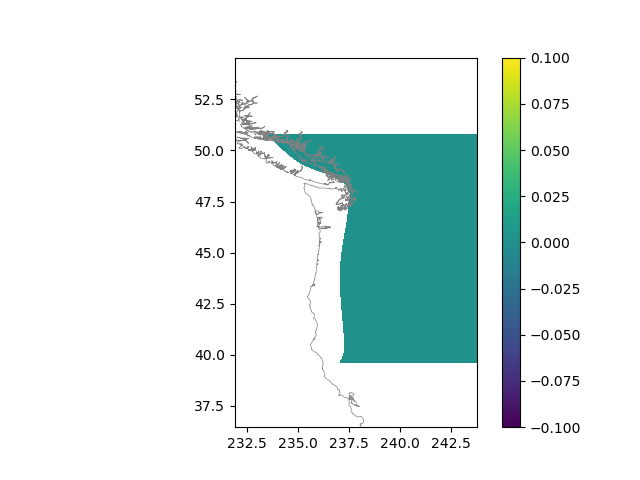

In [62]:
# experimentation for strike and dip values
strike_list = mesh["strike"]
print(np.median(strike_list))

strike_count = 0
for i in strike_list:
    if i == 180.0:
        strike_count += 1

print(strike_count)

dip_list = mesh["dip"]
dip_list.sort()

nv_list = mesh["nv"]

mesh["dip"][2979] = 0
mesh["dip"][2980] = 0
mesh["dip"][2981] = 0


#Show elements colored by dip
fig, ax = plt.subplots()
sto = ax.tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=mesh["dip"])
plt.colorbar(sto)
# Draw the fault
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()

In [63]:
# Calculate the mathematical relationship between unit fault slip and displacement
# This takes a bit of time, but it only needs to be done once if your fault and grid don't change

import cutde.halfspace as cutde

disp_mat = cutde.disp_matrix(obs_pts=cart_grid_pts, tris=cart_fault_pts[mesh["verts"]], nu=0.25)

# Write to HDF5 file
hf = h5py.File("horiz_disp_mat.h5", "w")
hf["horiz_disp_mat"] = disp_mat
hf.close()

In [64]:
# Read disp_mat from file

hf_horiz = h5py.File('horiz_disp_mat.h5', 'r')
horiz_disp_mat = np.array(hf_horiz["horiz_disp_mat"])
hf_horiz.close()

hf_casc = h5py.File('casc_disp_mat.h5', 'r')
casc_disp_mat = np.array(hf_casc["casc_disp_mat"])
hf_casc.close()

In [65]:
def radgauss(x0, y0, a, x, y, c):
# 
# RADGAUSS calculates a radial Gaussian distribution.
# 
# S = RADGAUSS(X0, Y0, A, X, Y, C) uses the formula:
# 
# S(Xi, Yi) = A exp(-Ri^2/2C^2)
# 
# to calculate the value S at point (Xi,Yi), which is located a distance
# Ri from point (X0,Y0), where the value is A.  C represents a Gaussian 
# curvature parameter: larger values of C produce more abrupt changes in
# value with distance.
# 
# X0, Y0 represent the x,y coordinates of the point of maximum magnitude A.
# X and Y are n x 1 arrays containing the x,y coordinates of all points at
# which the value S should be calculated.  C is a single value that applies
# to the entire calculation.
# 
# If C is a 2-element vector, the pattern will not be radial but elliptical,
# with the first element of C giving the curvature in the X direction and the
# second giving the curvature in Y:
# 
# S(Xi, Yi) = A exp( [ -(Xi-X0)^2 / 2C[0]^2 ] + [ -(Yi-Y0)^2 / 2C[1]^2] )
# 
# If C is a 3-element vector, an elliptical pattern will result, and the
# ellipse will be rotated C[2] degrees from the y-axis, where a positive 
# number gives a clockwise rotation.
    c = np.array(c)
    if np.size(c) == 1:
        r = np.sqrt((x-x0)**2+(y-y0)**2) # calculate distances
        s = a*np.exp(-r**2/(2*c**2)) # calculate Gaussian value
    elif np.size(c) == 2:
        s = a*np.exp((-(x-x0)**2./(2*c[0]**2)) + (-(y-y0)**2./(2*c[1]**2)))
    elif np.size(c) == 3:
        ang = np.deg2rad(c[2])
        rot = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
        coords = np.vstack((np.hstack((x.T, x0)), np.hstack((y.T, y0))))
        rcoords = rot.dot(coords)
        s = a*np.exp((-(rcoords[0, :-1]-rcoords[0, -1])**2/(2*c[0]**2)) + (-(rcoords[1, :-1]-rcoords[1, -1])**2/(2*c[1]**2)))

    return s  

## Radial Slip and Resulting Grid Displacement

This code generates a map with the added slip and a grid displacement color plot, with red representing the positive direction (north, east, up) and blue representing the negative direction (south, west, down). ```lon_center``` and ```lat_center``` represent the center of the slip; and ```slip_shape``` creates the circle of slip based on x and y stretch and the rotation angle.
- To place slip on different axises:
    - *Strike slip*: ```slip = np.vstack((s, zeros, zeros))```
    - *Dip slip*: ```slip = np.vstack((zeros, s, zeros))```
    - *Tensile slip*: ```slip = np.vstack((zeros, zeros, s))```
- To record different grid displacement directions:
    - *North-south*: ```horiz_plot_disp = horiz_pred_disp[0::3]```
    - *East-west*: : ```horiz_plot_disp = horiz_pred_disp[1::3]```
    - *Up-down*: : ```horiz_plot_disp = horiz_pred_disp[2::3]```

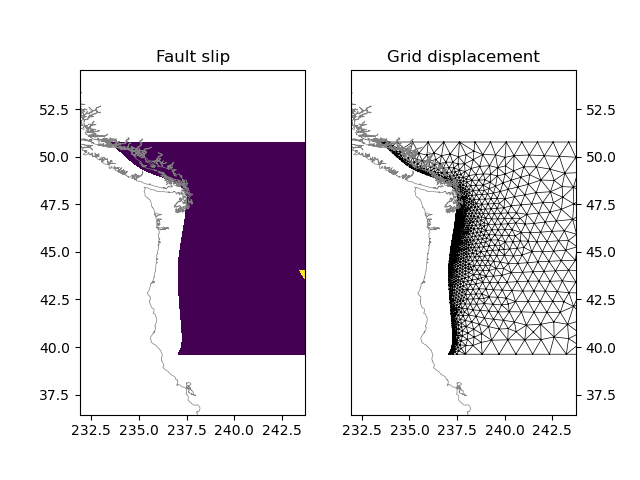

In [66]:
# Uniform fault slip distribution 
# slip = np.zeros_like(mesh["verts"])
# slip[:, 1] = 1 # Uniform dip-slip

# Radial slip distribution 

# Center coordinates of slip distribution
lon_center = 239 
lat_center = 41
# Stretch of slip gradient in x, y plus rotation angle
slip_shape = np.array([1, 1, 0])
s = radgauss(lon_center, lat_center, 1, mesh["centroids"][:, 0], mesh["centroids"][:, 1], slip_shape)


# Create full slip distribution, adding radial slip as dip-slip 
# s in the first position for strike-slip
# s in the second position for dip-slip
# s in the third position for tensile slip
# slip = np.vstack((s, np.zeros_like(s), np.zeros_like(s))).T
slip = np.zeros_like(mesh["nv"])
test_element = 14
slip[test_element, 2] = 1

# Calculate predicted displacement at grid points that arises from fault slip
horiz_pred_disp = horiz_disp_mat.reshape((-1, 3*ntri)).dot(slip.reshape(3*ntri, 1))

plt.close('all')
# Visualize the slip and displacement pattern 
fig, ax = plt.subplots(1, 2)
fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=np.sum(slip, axis=1))
# fig.colorbar(fso, ax=ax[0], orientation='horizontal')
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0].title.set_text("Fault slip")
# Show uplift (horiz_pred_disp[2::3])

# Get limits of displacement that is being plotted
# horiz_plot_disp = horiz_pred_disp[2::3]
horiz_plot_disp = horiz_pred_disp[2::3] 
# 0 3
max_mag = np.max([np.max(horiz_plot_disp), np.abs(np.min(horiz_plot_disp))])
gdo = ax[1].pcolormesh(obsx, obsy, horiz_plot_disp.reshape(np.shape(obsx)), shading="auto", cmap="bwr", vmin=-max_mag, vmax=max_mag)
# Draw the fault
ax[1].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5, color='k')
# Add coastline
ax[1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1].yaxis.tick_right()
ax[1].title.set_text("Grid displacement")
plt.show()

## Detailed Grid Displacement Plots

This code generates four plots. The first is the shape of the slip itself, as with above. Then grid displacement is visualized on all three axises. The second is a vector plot of north/east, from the top down. The third and fourth compare east/up and north/up respectively from side profiles. ```subset``` can be changed to make the vectors closer or farther apart (ten is a good default). With these more detailed plot, we can better visualize exactly how the land might shift in a 3D space.

c:\Users\jmjordan\AppData\Local\anaconda3\envs\faultdis\Lib\site-packages\matplotlib\quiver.py:676: RuntimeWarning: Mean of empty slice.
  amean = a[~self.Umask].mean()
c:\Users\jmjordan\AppData\Local\anaconda3\envs\faultdis\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


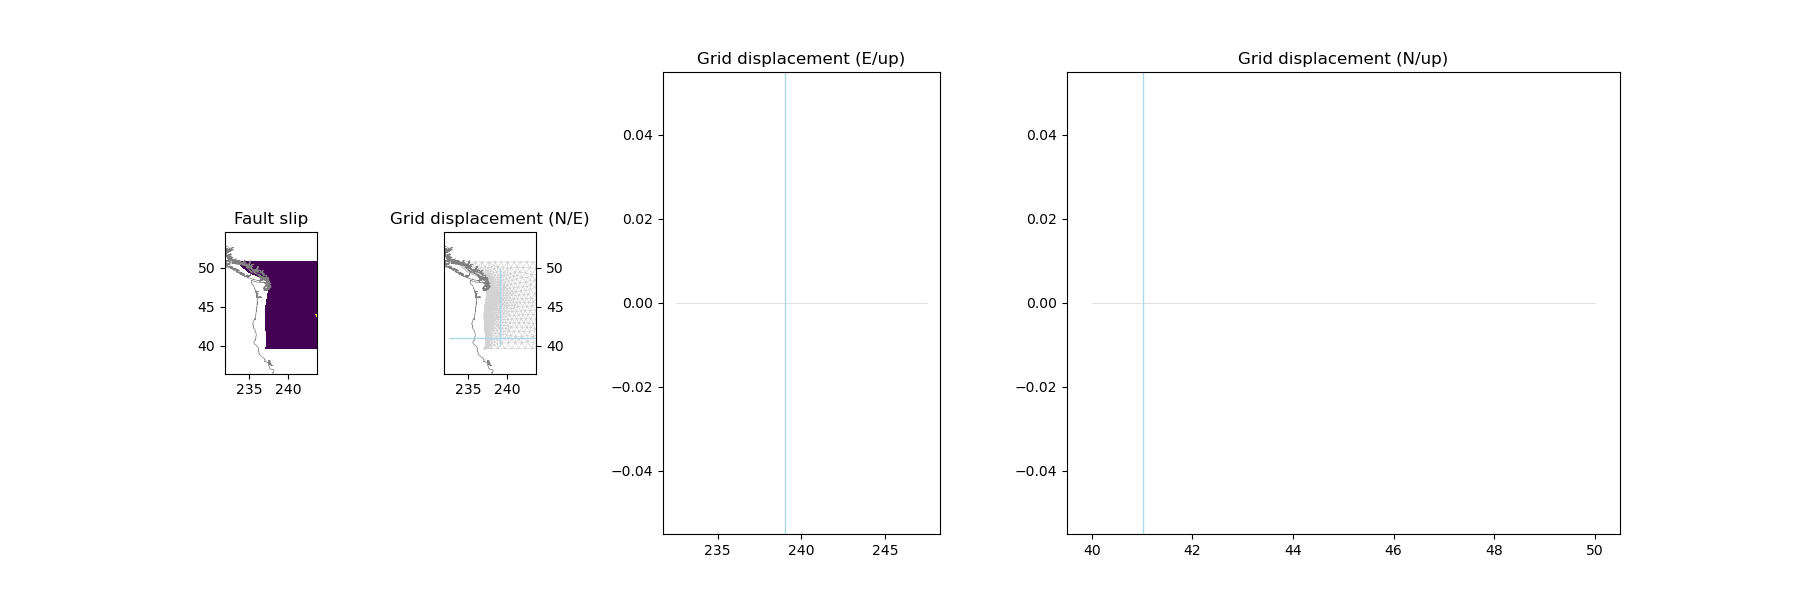

In [67]:
# vectors

plt.close('all')
# Visualize the slip and displacement pattern 
fig, ax = plt.subplots(1, 4, width_ratios=(1, 1, 3, 6))
fig.set_size_inches(18, 6)
fig.subplots_adjust(wspace=(1/2))
fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=np.sum(slip, axis=1))
# fig.colorbar(fso, ax=ax[0], orientation='horizontal')
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0].title.set_text("Fault slip")
# Show uplift (horiz_pred_disp[2::3])

# Get limits of displacement that is being plotted
# horiz_plot_disp = horiz_pred_disp[2::3]
# 0 3
max_mag = np.max([np.max(horiz_plot_disp), np.abs(np.min(horiz_plot_disp))])
east_disp = horiz_pred_disp[0::3].reshape(np.shape(obsx))
north_disp = horiz_pred_disp[1::3].reshape(np.shape(obsx))
up_disp = horiz_pred_disp[2::3].reshape(np.shape(obsx))
row_idx = np.argmin(np.abs(obsy[:,0] - lat_center))
column_idx = np.argmin(np.abs(obsx[0:,] - lon_center))
    

subset = 10
gdo = ax[1].quiver(obsx[::subset, ::subset], obsy[::subset, ::subset], east_disp[::subset, ::subset], north_disp[::subset, ::subset], width = 0.010, color="r")
# Draw the fault
ax[1].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5, color='lightgray')
# Add coastline
ax[1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1].hlines(obsy[row_idx, 0], np.min(obsx), np.max(obsx), linewidth=1, color="lightblue")
ax[1].vlines(obsx[0, column_idx], np.min(obsy), np.max(obsy), linewidth=1, color="lightblue")
ax[1].yaxis.tick_right()
ax[1].title.set_text("Grid displacement (N/E)")

vec_scale = 2
ax[2].hlines(0, np.min(obsx), np.max(obsx), linewidth=0.5, color="lightgray")
ax[2].quiver(obsx[row_idx, ::subset], 0 * obsx[row_idx, ::subset], east_disp[row_idx, ::subset], up_disp[row_idx, ::subset], scale = vec_scale)
y_range = ax[2].get_ylim()
ax[2].vlines(obsx[0, column_idx], y_range[0], y_range[1], linewidth=1, color="lightblue")
ax[2].set_ylim(y_range)
ax[2].title.set_text("Grid displacement (E/up)")

ax[3].hlines(0, np.min(obsy), np.max(obsy), linewidth=0.5, color="lightgray")
ax[3].quiver(obsy[::subset, column_idx], 0 * obsy[::subset, column_idx], north_disp[::subset, column_idx], up_disp[::subset, column_idx], scale = vec_scale)
y_range = ax[3].get_ylim()
ax[3].vlines(obsy[row_idx, 0], y_range[0], y_range[1], linewidth=1, color="lightblue")
ax[3].set_ylim(y_range)
ax[3].title.set_text("Grid displacement (N/up)")

plt.show()

## Corner Flow Representation

This code reads in the cascadia mesh (a 3D representation of the fault) and finds the coordinates of the deepest part. which corresponds to the western edge of the horizontal mesh. The minimum distance between each point on the grid and the deepest points is calculated and then  scaled from 0 to 1. Tensile slip is calculated based on that scaled distance, so the furthest points have the least slip and the westernmost points have the most. Those distances are then multiplied by the ```s_factor```, which represents the weight of the slip.

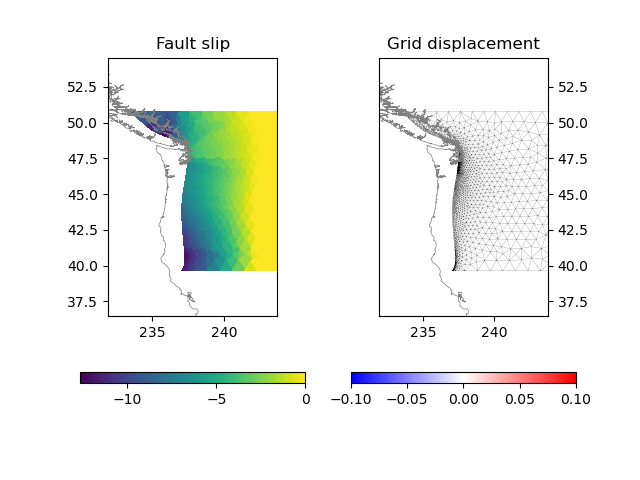

In [68]:
# width radtios on vector plots
# move vertical line back

min_depth = np.min(casc_mesh["points"][casc_mesh["verts"], 2])
# Get the indices of the points whose depths are the minuimum
deepest_points_indices = np.where(casc_mesh["points"][:, 2] == min_depth)[0]
# Get the actual coordinates of these indices
deepest_points = casc_mesh["points"][deepest_points_indices, :]

dist_dif = np.zeros(len(mesh["centroids"]))

for i in range(len(mesh["centroids"])):
    dist_dif[i] = np.min(np.sqrt((deepest_points[:, 0] - mesh["centroids"][i, 0])**2 + (deepest_points[:, 1] - mesh["centroids"][i, 1])**2))
    
dist_dif = 1 - dist_dif / 5
dist_dif[dist_dif < 0] = 0
s = dist_dif * 35
conv_direction = 30
s_factor = 1
# adjust max by 5 degrees, zero out negatives

#casc mesh centroid calculations
horiz_distance = np.zeros(len(mesh["centroids"]))
horiz_distance = np.sqrt((casc_mesh["centroids"][:, 0] - mesh["centroids"][i, 0])**2 + (casc_mesh["centroids"][:, 1] - mesh["centroids"][i, 1])**2)

closest_fault_el = np.zeros(len(mesh["centroids"])).astype(int)
for i in range(len(mesh["centroids"])):
    closest_fault_el[i] = np.argmin(np.sqrt((casc_mesh["centroids"][:, 0] - mesh["centroids"][i, 0])**2 + (casc_mesh["centroids"][:, 1] - mesh["centroids"][i, 1])**2))
closest_fault_dip = casc_mesh["dip"][closest_fault_el]
tensile_slip = s * np.sin(np.radians(closest_fault_dip))
horiz_slip = s * np.cos(np.radians(closest_fault_dip))
strike_slip = horiz_slip * np.cos(np.radians(conv_direction))
dip_slip = horiz_slip * np.sin(np.radians(conv_direction))

# Create full slip distribution, adding radial slip as dip-slip 
# s in the first position for strike-slip
# s in the second position for dip-slip
# s in the third position for tensile slip
# slip = np.vstack((s * np.cos(np.radians(conv_direction)), s * np.sin(np.radians(conv_direction)), s * s_factor)).T
# slip = np.zeros_like(mesh["nv"])
# test_element = 127
# slip[test_element, 1] = 1

slip = np.vstack((strike_slip, dip_slip, -tensile_slip)).T

# Calculate predicted displacement at grid points that arises from fault slip
horiz_pred_disp = horiz_disp_mat.reshape((-1, 3*ntri)).dot(slip.reshape(3*ntri, 1))

plt.close('all')
# Visualize the slip and displacement pattern 
fig, ax = plt.subplots(1, 2)
# fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=np.sum(slip, axis=1))
fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=slip[:,2])
fig.colorbar(fso, ax=ax[0], orientation='horizontal')
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0].title.set_text("Fault slip")
# Show uplift (horiz_pred_disp[2::3])

# Get limits of displacement that is being plotted
# horiz_plot_disp = horiz_pred_disp[2::3]
horiz_plot_disp = horiz_pred_disp[2::3] 
# 0 3
max_mag = np.max([np.max(horiz_plot_disp), np.abs(np.min(horiz_plot_disp))])
gdo = ax[1].pcolormesh(obsx, obsy, horiz_plot_disp.reshape(np.shape(obsx)), shading="auto", cmap="bwr", vmin=-max_mag, vmax=max_mag)


# Draw the fault
ax[1].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.1, color='k')
# Add coastline
ax[1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1].yaxis.tick_right()
ax[1].title.set_text("Grid displacement")
# Add colorbar
fig.colorbar(gdo, ax=ax[1], orientation='horizontal')
plt.show()


In [69]:
i = 0
horiz_distance = np.sqrt((casc_mesh["centroids"][:, 0] - mesh["centroids"][i, 0])**2 + (casc_mesh["centroids"][:, 1] - mesh["centroids"][i, 1])**2)


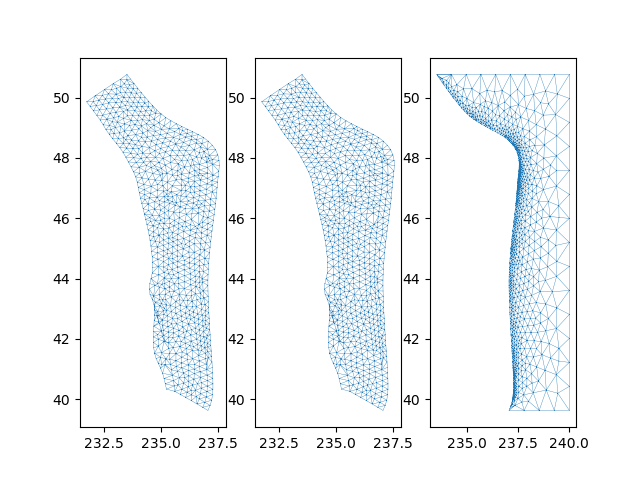

check


In [70]:
# Read and parse hanna's mesh
he_mesh = dict()
he_meshobj = meshio.read("saux_50km_lon_lat.msh")
he_mesh["points"] = he_meshobj.points
he_mesh["verts"] = meshio.CellBlock("triangle", he_meshobj.get_cells_type("triangle")).data

he_mesh["lon1"] = he_mesh["points"][he_mesh["verts"][:, 0], 0]
he_mesh["lon2"] = he_mesh["points"][he_mesh["verts"][:, 1], 0]
he_mesh["lon3"] = he_mesh["points"][he_mesh["verts"][:, 2], 0]
he_mesh["lat1"] = he_mesh["points"][he_mesh["verts"][:, 0], 1]
he_mesh["lat2"] = he_mesh["points"][he_mesh["verts"][:, 1], 1]
he_mesh["lat3"] = he_mesh["points"][he_mesh["verts"][:, 2], 1]
he_mesh["dep1"] = he_mesh["points"][he_mesh["verts"][:, 0], 2]
he_mesh["dep2"] = he_mesh["points"][he_mesh["verts"][:, 1], 2]
he_mesh["dep3"] = he_mesh["points"][he_mesh["verts"][:, 2], 2]
he_mesh["centroids"] = np.mean(he_mesh["points"][he_mesh["verts"], :], axis=1)

# read and parse horiz
horiz = dict()
horizobj = meshio.read("horiz.msh")
horiz["points"] = horizobj.points
horiz["verts"] = meshio.CellBlock("triangle", horizobj.get_cells_type("triangle")).data
fig, ax = plt.subplots(1, 3)
# compare he_mesh with he_mesh and horiz_mesh
ax[0].triplot(he_mesh["points"][:, 0], he_mesh["points"][:, 1], he_mesh["verts"], linewidth=0.25)
ax[1].triplot(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], linewidth=0.25)
ax[2].triplot(horiz["points"][:, 0], horiz["points"][:, 1], horiz["verts"], linewidth=0.25)
plt.show()

if (he_mesh["lon1"] == casc_mesh["lon1"]).all():
    print("check")

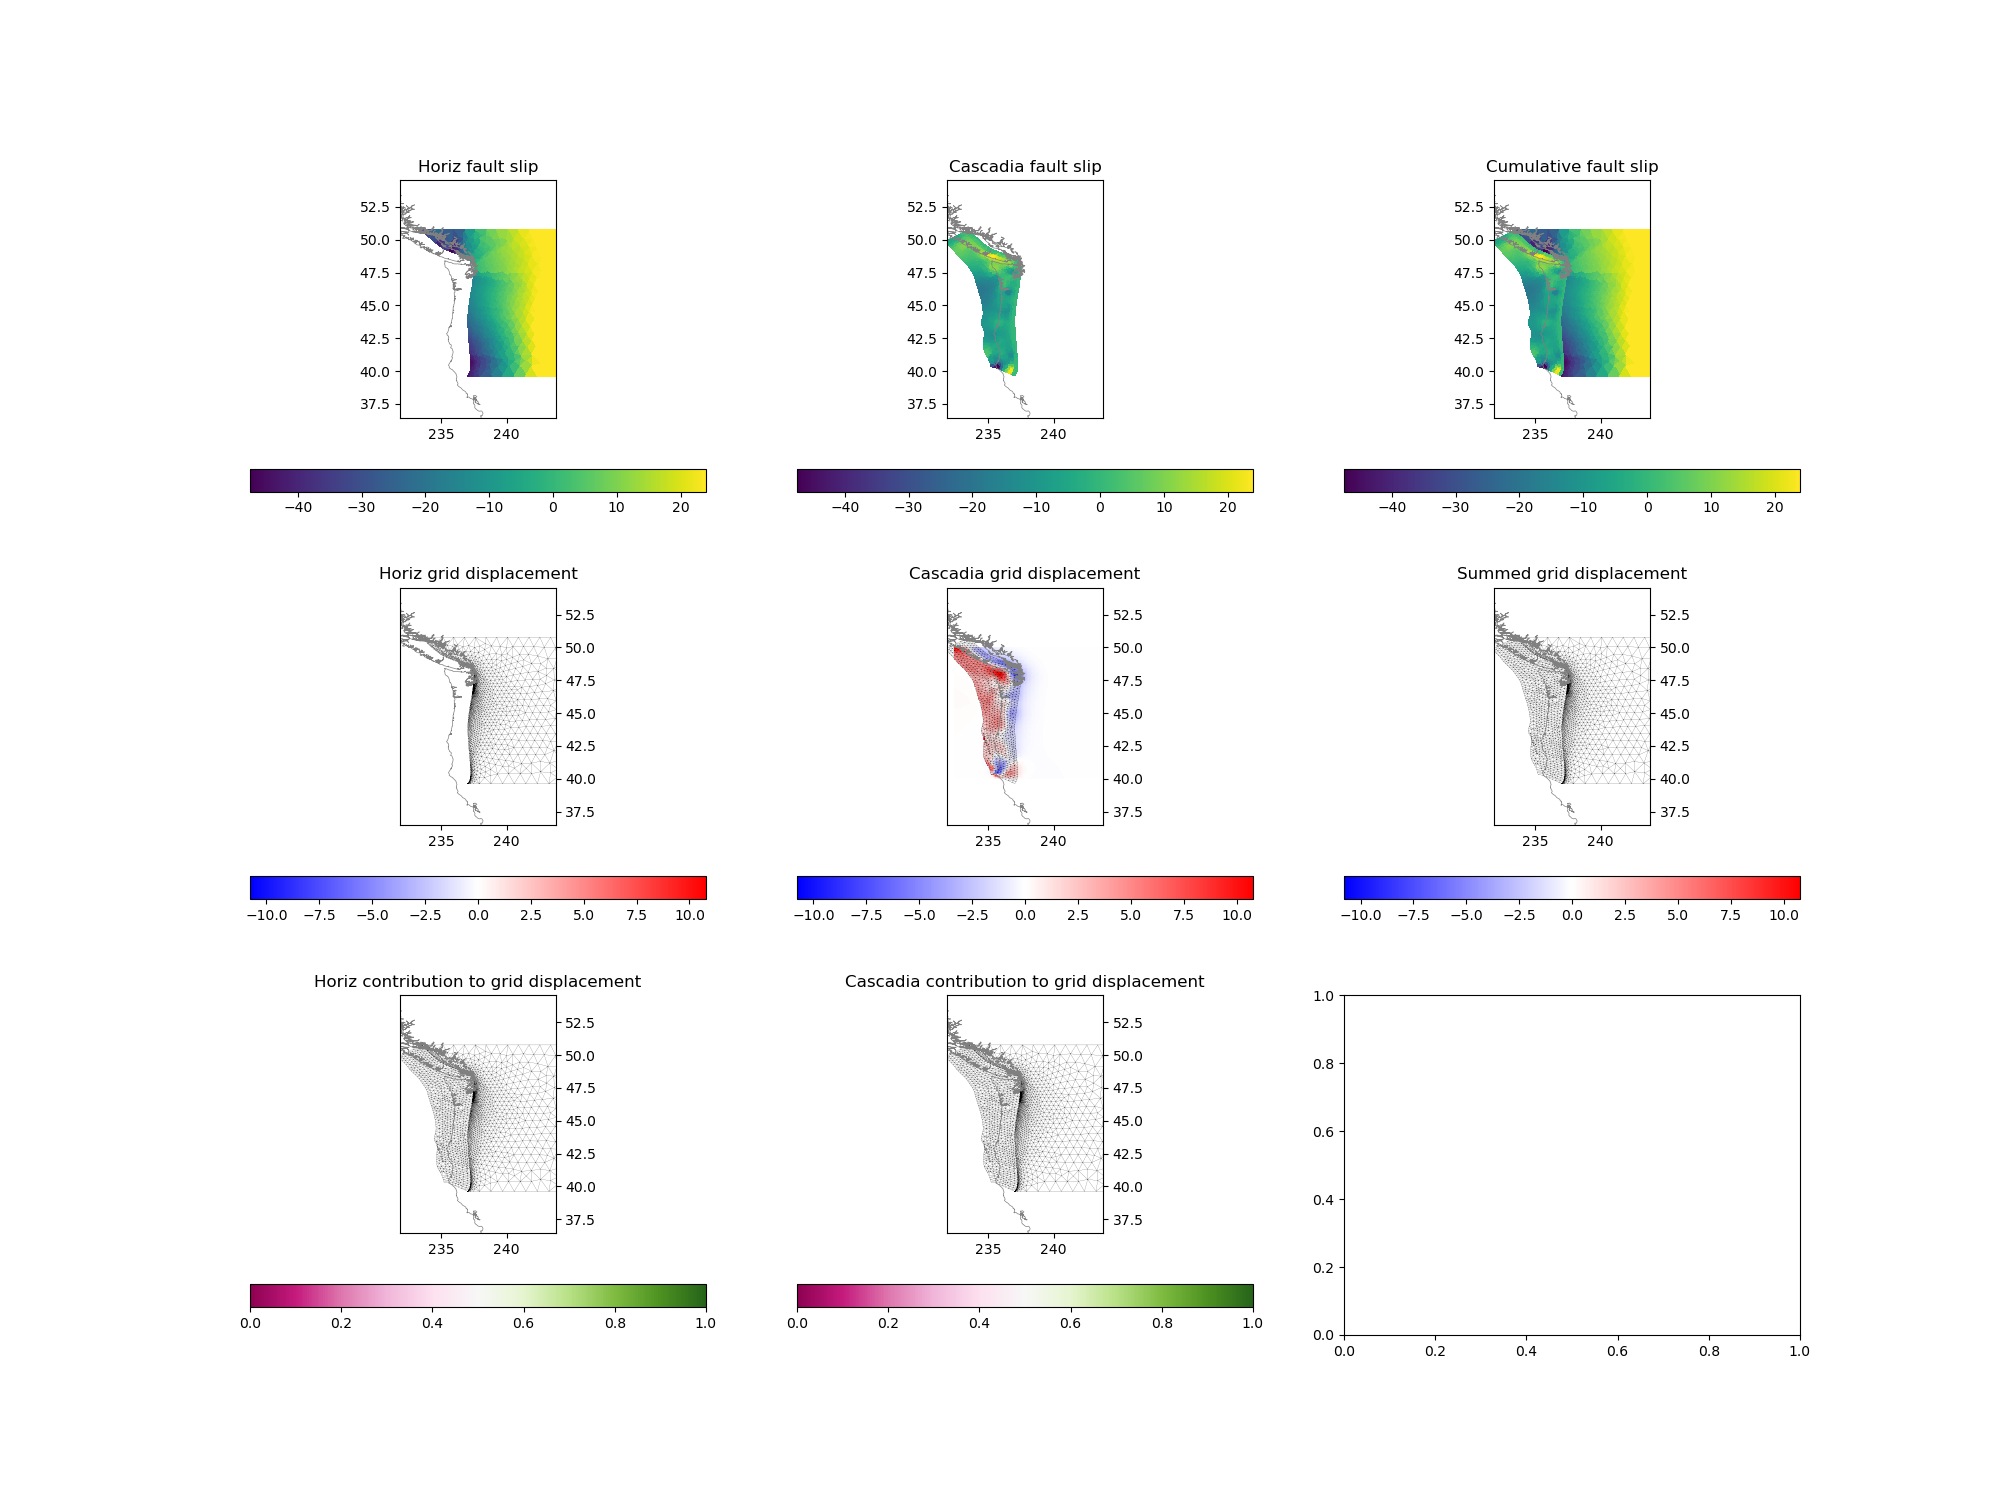

In [71]:
casc_ntri = len(he_mesh["verts"])
he_slip = pd.read_csv("saux_50km_contiguous.txt", sep="\t", names=["strike", "dip"])
he_slip = he_slip.to_numpy()
fig, ax = plt.subplots(3, 3, figsize=(20, 15))
he_strike = he_slip[:, 0]
# ax.tripcolor(he_mesh["points"][:, 0], he_mesh["points"][:, 1], he_mesh["verts"], he_slip[:, 0])

casc_tensile_slip = []
for i in range(casc_ntri):
    casc_tensile_slip.append(0)

he_slip = np.column_stack((he_slip, casc_tensile_slip))
# Cascadia Slip
casc_pred_disp = casc_disp_mat.reshape((-1, 3*casc_ntri)).dot(he_slip.reshape(3*casc_ntri, 1))
casc_plot_disp = casc_pred_disp[2::3] 
casc_max_mag = np.max([np.max(casc_plot_disp), np.abs(np.min(casc_plot_disp))])

# cascadia points
cxs = np.linspace(231, 238, 100)
cys = np.linspace(40, 50, 100)
cobsx, cobsy = np.meshgrid(cxs, cys)
cxmin = np.mean(casc_mesh["points"][:, 0]) - 3*np.std(casc_mesh["points"][:, 0])
cxmax = np.mean(casc_mesh["points"][:, 0]) + 3*np.std(casc_mesh["points"][:, 0])
cymin = np.mean(casc_mesh["points"][:, 1]) - 3*np.std(casc_mesh["points"][:, 1])
cymax = np.mean(casc_mesh["points"][:, 1]) + 3*np.std(casc_mesh["points"][:, 1])

# combined points
all_points = np.vstack((casc_mesh["points"], mesh["points"]))
all_verts = np.vstack((casc_mesh["verts"], mesh["verts"]))

# horiz fault slip
ax[0, 0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0, 0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0, 0].title.set_text("Horiz fault slip")
hfso = ax[0, 0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=slip[:,2])

# horiz grid displacement
ax[1, 0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1, 0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1, 0].yaxis.tick_right()
ax[1, 0].title.set_text("Horiz grid displacement")
hgdo = ax[1, 0].pcolormesh(obsx, obsy, horiz_plot_disp.reshape(np.shape(obsx)), shading="auto", cmap="bwr", vmin=-max_mag, vmax=max_mag)
ax[1, 0].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.1, color='k')

# cascadia fault slip
ax[0, 1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0, 1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0, 1].title.set_text("Cascadia fault slip")
cfso = ax[0, 1].tripcolor(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], facecolors=he_slip[:,0])

# cascadia grid displacement
ax[1, 1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1, 1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1, 1].yaxis.tick_right()
ax[1, 1].title.set_text("Cascadia grid displacement")
cgdo = ax[1, 1].pcolormesh(obsx, obsy, casc_plot_disp.reshape(np.shape(obsx)), shading="auto", cmap="bwr", vmin=-casc_max_mag, vmax=casc_max_mag)
ax[1, 1].triplot(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], linewidth=0.1, color='k')

# summed fault slip
ax[0, 2].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0, 2].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0, 2].title.set_text("Cumulative fault slip")
cfso = ax[0, 2].tripcolor(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], facecolors=he_slip[:,0])
hfso = ax[0, 2].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=slip[:,2])

# summed grid displacement
ax[1, 2].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1, 2].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1, 2].yaxis.tick_right()
ax[1, 2].title.set_text("Summed grid displacement")
agdo = ax[1, 2].pcolormesh(obsx, obsy, casc_plot_disp.reshape(np.shape(obsx)) + horiz_plot_disp.reshape(np.shape(obsx)), shading="auto", cmap="bwr", vmin=-casc_max_mag, vmax=casc_max_mag)
# ax[1, 2].triplot(all_points[:, 0], all_points[:, 1], all_verts, linewidth=0.1, color='k')
ax[1, 2].triplot(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], linewidth=0.1, color='k')
ax[1, 2].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.1, color='k')

# equal colorbars
fig.colorbar(cfso, ax=ax[0, 0], orientation='horizontal')
fig.colorbar(cfso, ax=ax[0, 1], orientation='horizontal')
fig.colorbar(cfso, ax=ax[0, 2], orientation='horizontal')
fig.colorbar(agdo, ax=ax[1, 0], orientation='horizontal')
fig.colorbar(agdo, ax=ax[1, 1], orientation='horizontal')
fig.colorbar(agdo, ax=ax[1, 2], orientation='horizontal')

# contribution calculations
hcont = np.abs((horiz_plot_disp.reshape(np.shape(obsx))) / (casc_plot_disp.reshape(np.shape(obsx)) + horiz_plot_disp.reshape(np.shape(obsx))))
ccont = np.abs((casc_plot_disp.reshape(np.shape(obsx))) / (casc_plot_disp.reshape(np.shape(obsx)) + horiz_plot_disp.reshape(np.shape(obsx))))

# horiz contribution to grid displacement
ax[2, 0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[2, 0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[2, 0].yaxis.tick_right()
ax[2, 0].title.set_text("Horiz contribution to grid displacement")
hcont_gdo = ax[2, 0].pcolormesh(obsx, obsy, hcont, shading="auto", cmap="PiYG", vmin=0, vmax=1)
ax[2, 0].triplot(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], linewidth=0.1, color='k')
ax[2, 0].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.1, color='k')
fig.colorbar(hcont_gdo, ax=ax[2, 0], orientation='horizontal')

# casc contribution to grid displacement
ax[2, 1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[2, 1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[2, 1].yaxis.tick_right()
ax[2, 1].title.set_text("Cascadia contribution to grid displacement")
ccont_gdo = ax[2, 1].pcolormesh(obsx, obsy, ccont, shading="auto", cmap="PiYG", vmin=0, vmax=1)
ax[2, 1].triplot(casc_mesh["points"][:, 0], casc_mesh["points"][:, 1], casc_mesh["verts"], linewidth=0.1, color='k')
ax[2, 1].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.1, color='k')
fig.colorbar(ccont_gdo, ax=ax[2, 1], orientation='horizontal')


In [72]:
'''
filename = "horiz.msh"
# filename = "japan.msh"
mesh = dict()
meshobj = meshio.read(filename)
mesh["file_name"] = filename
mesh["points"] = meshobj.points
mesh["verts"] = meshio.CellBlock("triangle", meshobj.get_cells_type("triangle")).data
ntri = len(mesh["verts"])

# Expand mesh coordinates
mesh["lon1"] = mesh["points"][mesh["verts"][:, 0], 0]
mesh["lon2"] = mesh["points"][mesh["verts"][:, 1], 0]
mesh["lon3"] = mesh["points"][mesh["verts"][:, 2], 0]
mesh["lat1"] = mesh["points"][mesh["verts"][:, 0], 1]
mesh["lat2"] = mesh["points"][mesh["verts"][:, 1], 1]
mesh["lat3"] = mesh["points"][mesh["verts"][:, 2], 1]
mesh["dep1"] = mesh["points"][mesh["verts"][:, 0], 2]
mesh["dep2"] = mesh["points"][mesh["verts"][:, 1], 2]
mesh["dep3"] = mesh["points"][mesh["verts"][:, 2], 2]
mesh["centroids"] = np.mean(mesh["points"][mesh["verts"], :], axis=1)

# Cross products for orientations
tri_leg1 = np.transpose([np.deg2rad(mesh["lon2"] - mesh["lon1"]), np.deg2rad(mesh["lat2"] - mesh["lat1"]), (1 + KM2M * mesh["dep2"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep1"] / RADIUS_EARTH)])
tri_leg2 = np.transpose([np.deg2rad(mesh["lon3"] - mesh["lon2"]), np.deg2rad(mesh["lat3"] - mesh["lat2"]), (1 + KM2M * mesh["dep3"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep2"] / RADIUS_EARTH)])
# swapping tri_leg 1 and 2 to reorient strike
mesh["nv"] = np.cross(tri_leg2, tri_leg1)
azimuth, elevation, r = cart2sph(mesh["nv"][:, 0], mesh["nv"][:, 1], mesh["nv"][:, 2])
mesh["strike"] = wrap2360(-np.rad2deg(azimuth))
mesh["dip"] = 90 - np.rad2deg(elevation)
mesh["dip_flag"] = mesh["dip"] != 90
'''

'\nfilename = "horiz.msh"\n# filename = "japan.msh"\nmesh = dict()\nmeshobj = meshio.read(filename)\nmesh["file_name"] = filename\nmesh["points"] = meshobj.points\nmesh["verts"] = meshio.CellBlock("triangle", meshobj.get_cells_type("triangle")).data\nntri = len(mesh["verts"])\n\n# Expand mesh coordinates\nmesh["lon1"] = mesh["points"][mesh["verts"][:, 0], 0]\nmesh["lon2"] = mesh["points"][mesh["verts"][:, 1], 0]\nmesh["lon3"] = mesh["points"][mesh["verts"][:, 2], 0]\nmesh["lat1"] = mesh["points"][mesh["verts"][:, 0], 1]\nmesh["lat2"] = mesh["points"][mesh["verts"][:, 1], 1]\nmesh["lat3"] = mesh["points"][mesh["verts"][:, 2], 1]\nmesh["dep1"] = mesh["points"][mesh["verts"][:, 0], 2]\nmesh["dep2"] = mesh["points"][mesh["verts"][:, 1], 2]\nmesh["dep3"] = mesh["points"][mesh["verts"][:, 2], 2]\nmesh["centroids"] = np.mean(mesh["points"][mesh["verts"], :], axis=1)\n\n# Cross products for orientations\ntri_leg1 = np.transpose([np.deg2rad(mesh["lon2"] - mesh["lon1"]), np.deg2rad(mesh["lat2"] 

## Next Steps

- scale mantle flow simulations more realistically
- comparing mantle flow simulations to real world data
- go through scientific literature for resources about viscoelastic flow and coupling
- combine Hannah's fault based work with mantle flow simulations

## Action Items
X s scaling
X refamiliarize with figures
X added color bars 
- disp_mat for cascadia

## Notes
 - fault slip scaling max to 35 mm? 
 - much less blue +35 mm
 - numbers depend on s-factor, range from (-5, 8) at zero and (0, 28) at 1
 - at one s-factor: all strong positive 1:3 and 2:3 (north, up disp); shows slight blue at 0:3 (eastward land has westward slip, coastline shows east slip)
 - why is fault slip so high?